In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
three_mer_mutation_info_df = pd.read_csv('./data/human.strand_specific.mut_info.tsv', sep='\t')

In [3]:
# Mask & poisson correction
three_mer_mutation_info_df['density (corrected)'] = -np.log(
    1 - (three_mer_mutation_info_df['mutation total num'] / (three_mer_mutation_info_df['total site'] - three_mer_mutation_info_df['total mask']))
)
three_mer_mutation_info_df['density (corrected)'].fillna(0, inplace=True)

In [4]:
# Scale composition to reference
reference_gene_group_region = ('Expressed genes', 'transcript')
reference_df = three_mer_mutation_info_df[
    (three_mer_mutation_info_df['gene group'] == reference_gene_group_region[0]) &
    (three_mer_mutation_info_df['region'] == reference_gene_group_region[1])
]
three_mer_count = reference_df.set_index('mutation').to_dict()['total site']

# Calculate 1-mer level mutation density
density_df_lst = []
gene_groups = three_mer_mutation_info_df['gene group'].unique()

for (species, region), df in three_mer_mutation_info_df.groupby(['species', 'region']):
    
    for gene_group in gene_groups:

        gene_df = df[df['gene group'] == gene_group]
        gene_df['total site'] = gene_df['mutation'].map(three_mer_count)
        gene_df['mutation total num (corrected)'] = gene_df['density (corrected)'] * gene_df['total site']
        # Identify 1-mer mutation (with CpG annotation)
        gene_df['1-mer mutation'] = gene_df['mutation'].apply(
            lambda x: f'{x[1]}>{x[-2]}' if 'CG' not in x[0:3] else f'{x[1]}>{x[-2]}(CpG)'
        )

        # Merge into 1-mer level
        for group, onemer_df in gene_df.groupby('1-mer mutation'):
            
            total_site = onemer_df['total site'].sum()
            total_mutation = onemer_df['mutation total num (corrected)'].sum()
            density_df_lst.append({
                'species': species,
                'gene group': gene_group,
                'region': region,
                '1-mer mutation': group,
                'total site': total_site,
                'total mutation': total_mutation,
                'density': total_mutation / total_site
            })

onemer_density_df = pd.DataFrame(density_df_lst)

In [5]:
asymmetry_df_lst = []
merge_density_df_lst = []
main_nucs = ['C', 'T']
complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}

for main_nuc in main_nucs:

    mut_nucs = {'A', 'C', 'G', 'T'} - {main_nuc}

    for (s, g, r), df in onemer_density_df.groupby(['species', 'gene group', 'region']):

        for mut_nuc in mut_nucs:

            transcribed_strand_mutation = f'{main_nuc}>{mut_nuc}'
            non_transcribed_strand_mutation = f'{complement[main_nuc]}>{complement[mut_nuc]}'

            transcribed_strand_density = df[df['1-mer mutation'] == transcribed_strand_mutation]['density'].values[0]
            non_transcribed_strand_density = df[df['1-mer mutation'] == non_transcribed_strand_mutation]['density'].values[0]

            asymmetry_score = -np.log2(non_transcribed_strand_density / transcribed_strand_density)
            asymmetry_df_lst.append({
                'species': s,
                'gene group': g,
                'region': r,
                'mutation': transcribed_strand_mutation,
                'asymmetry score': asymmetry_score
            })

            transcribed_strand_site = df[df['1-mer mutation'] == transcribed_strand_mutation]['total site'].values[0]
            non_transcribed_strand_site = df[df['1-mer mutation'] == non_transcribed_strand_mutation]['total site'].values[0]
            transcribed_strand_mutation_count = df[df['1-mer mutation'] == transcribed_strand_mutation]['total mutation'].values[0]
            non_transcribed_strand_mutation_count = df[df['1-mer mutation'] == non_transcribed_strand_mutation]['total mutation'].values[0]

            merge_density_df_lst.append({
                'species': s,
                'gene group': g,
                'region': r,
                'mutation': f'{transcribed_strand_mutation}&{non_transcribed_strand_mutation}',
                'density': (transcribed_strand_mutation_count + non_transcribed_strand_mutation_count) / (transcribed_strand_site + non_transcribed_strand_site)
            })

            if main_nuc in ['C', 'G']:

                transcribed_strand_mutation += '(CpG)'
                non_transcribed_strand_mutation += '(CpG)'

                transcribed_strand_site = df[df['1-mer mutation'] == transcribed_strand_mutation]['total site'].values[0]
                non_transcribed_strand_site = df[df['1-mer mutation'] == non_transcribed_strand_mutation]['total site'].values[0]
                transcribed_strand_mutation_count = df[df['1-mer mutation'] == transcribed_strand_mutation]['total mutation'].values[0]
                non_transcribed_strand_mutation_count = df[df['1-mer mutation'] == non_transcribed_strand_mutation]['total mutation'].values[0]

                merge_density_df_lst.append({
                    'species': s,
                    'gene group': g,
                    'region': r,
                    'mutation': f'{transcribed_strand_mutation.replace("(CpG)", "")}&{non_transcribed_strand_mutation}',
                    'density': (transcribed_strand_mutation_count + non_transcribed_strand_mutation_count) / (transcribed_strand_site + non_transcribed_strand_site)
                })

In [6]:
asymmetry_df = pd.DataFrame(asymmetry_df_lst).sort_values(by='mutation')
merge_density_df = pd.DataFrame(merge_density_df_lst).sort_values(by='mutation')

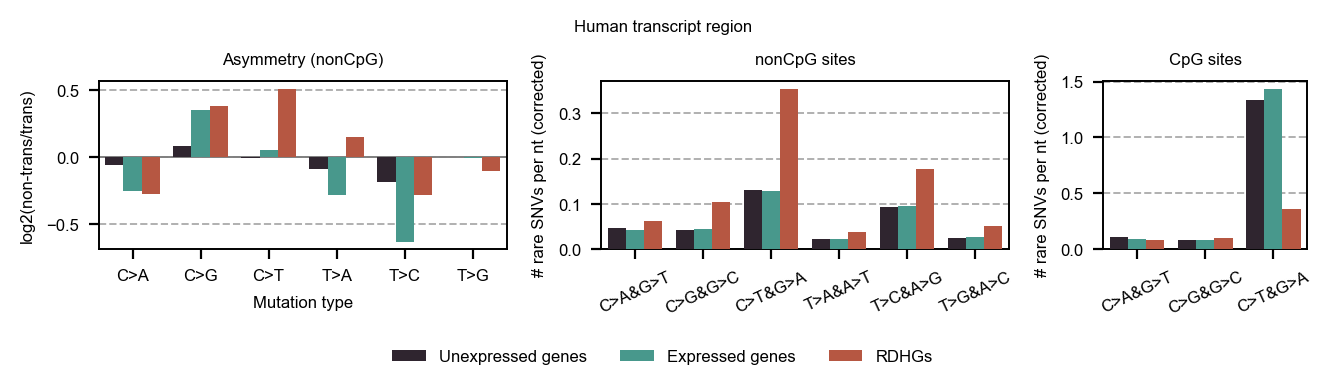

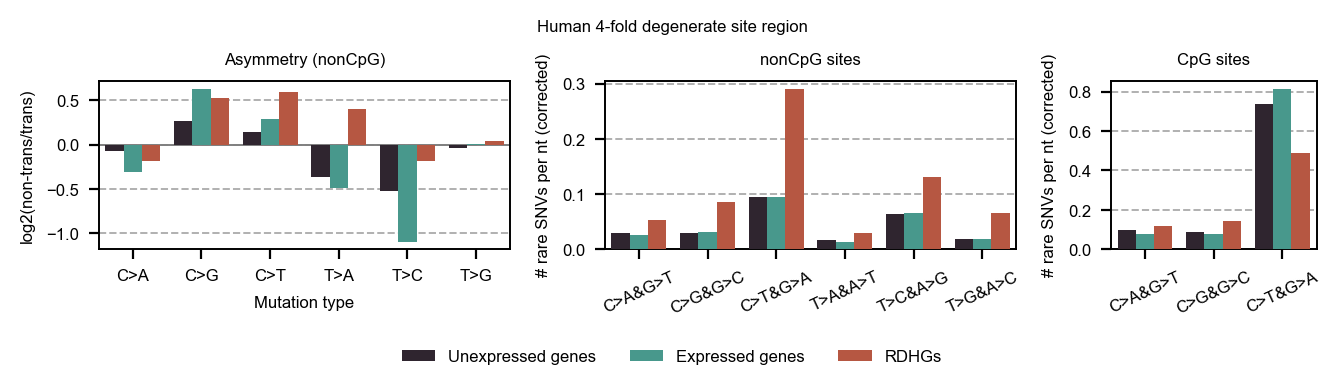

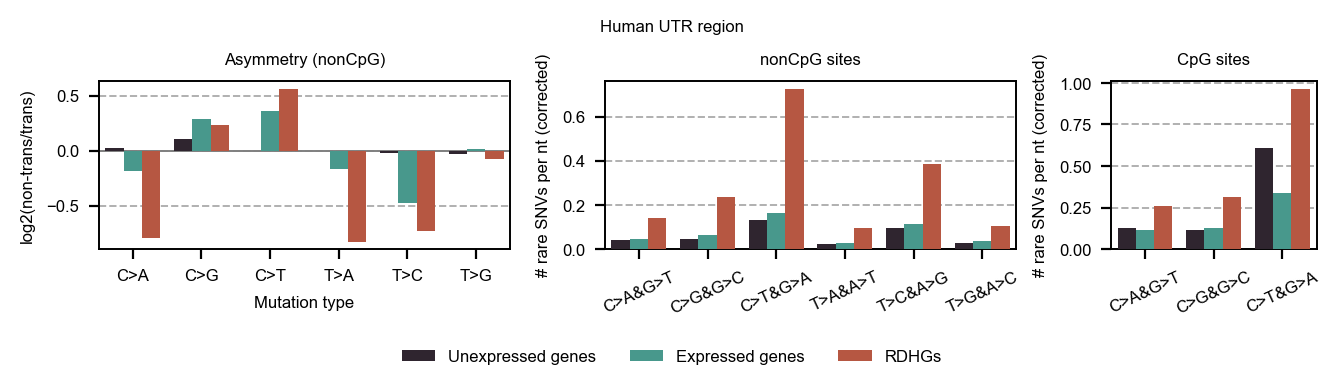

In [7]:
using_region_lst = ['transcript', '4dsite', 'UTR']
using_species_lst = ['human']

for using_species in using_species_lst:

    for using_region in using_region_lst:

        asymmetry_df_filter = (asymmetry_df['region'] == using_region) & (asymmetry_df['species'] == using_species)
        merge_density_df_filter = (merge_density_df['region'] == using_region) & (merge_density_df['species'] == using_species)
        # Color mapping
        color_mapping = {
            'RDHGs': '#CA4A2E', 
            'Expressed genes': '#3BA595',  
            'Unexpressed genes': '#302331' 
        }

        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(6.7, 1.5), width_ratios=[6, 6, 3])
        # Asymmetry
        sns.barplot(
            data=asymmetry_df[asymmetry_df_filter],
            x='mutation',
            y='asymmetry score',
            hue='gene group',
            hue_order=[
                'Unexpressed genes', 'Expressed genes', 'RDHGs'
            ],
            ax=axes[0],
            palette=color_mapping,
            zorder=3
        )
        # for i in range(0, 5):
        #     axes[0].axhline(i+0.5, color='black', linewidth=0.7)

        # 1-mer mutation density
        mr_result_df_noncpg = merge_density_df[
            ~merge_density_df['mutation'].str.contains('CpG')
        ]
        sns.barplot(
            data=mr_result_df_noncpg[merge_density_df_filter],
            x='mutation',
            y='density',
            hue='gene group',
            hue_order=[
                'Unexpressed genes', 'Expressed genes', 'RDHGs'
            ],
            ax=axes[1],
            palette=color_mapping,
            zorder=3
        )
        mr_result_df_cpg = merge_density_df[
            merge_density_df['mutation'].str.contains('CpG')
        ]
        mr_result_df_cpg['mutation'] = mr_result_df_cpg['mutation'].str.replace('(CpG)', '')
        sns.barplot(
            data=mr_result_df_cpg[merge_density_df_filter],
            x='mutation',
            y='density',
            hue='gene group',
            hue_order=[
                'Unexpressed genes', 'Expressed genes', 'RDHGs'
            ],
            ax=axes[2],
            palette=color_mapping,
            zorder=3
        )

        # Adjust figure
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=4, frameon=False)
        for ax in axes:
            # Remove legend
            ax.legend_.remove()
            ax.grid(axis='y', linestyle='--', linewidth=0.7, zorder=0)

        axes[0].set_xlabel('Mutation type')
        axes[0].set_ylabel('log2(non-trans/trans)')
        axes[0].set_title('Asymmetry (nonCpG)')
        axes[0].axhline(0, color='gray', linewidth=0.7, zorder=2)

        for ax in axes[1:]:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='center')
            ax.set_ylabel('# rare SNVs per nt (corrected)')
            ax.set_xlabel('')

        axes[1].set_title('nonCpG sites')
        axes[2].set_title('CpG sites')

        plt.tight_layout()
        fig.suptitle(f'{using_species.capitalize()} {using_region.replace("4dsite", "4-fold degenerate site")} region', y=1.05)